# <font color="steelblue">Algoritmo Naïve Bayes</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**

**Fecha última edición**: 08/06/2026

**Licencia**: <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>

No olvides hacer una copia si deseas utilizarlo.

In [1]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost
!pip install mlxtend --upgrade --no-deps
!pip install pingouin --upgrade
!pip install imbalanced-learn --upgrade

# Análisis numérico
import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.patches import Ellipse
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub

# Funciones de preprocesado, evaluación, CP y auto_ML
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'evaluar_clasificadores.py', 'pca_funciones.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from evaluar_clasificadores import *
from pca_funciones import *
from auto_ML import *

# Análisis discriminante y utilidades
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, learning_curve, GridSearchCV
from sklearn.feature_selection import RFE, f_classif
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_curve, roc_auc_score, make_scorer, f1_score, recall_score)
from sklearn.utils import resample
from mlxtend.plotting import plot_decision_regions
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
import pingouin
from sklearn.metrics import pairwise_distances

RNG = 42

# Naïve Bayes y utilidades
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.1 MB/s eta 0:00:00
  Attempting uninstall: mlxtend
    Found existing installation: mlxtend 0.23.4
    Uninstalling mlxtend-0.23.4:
      Successfully uninstalled mlxtend-0.23.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 2.9 MB/s eta 0:00:00


# <font color="steelblue">Introducción</font>

Imagina un detective que, ante un caso, combina pistas sueltas: "ha llovido", "la puerta estaba abierta", "el perro no ladró"… y, **suponiendo que cada pista es independiente de las demás**, va multiplicando indicios hasta decidir la hipótesis más probable. Esa es, en esencia, la idea de un **clasificador Naïve Bayes**: aplicar el **teorema de Bayes** para calcular la probabilidad de cada clase dadas las variables observadas, asumiendo —de forma deliberadamente *ingenua* (*naïve*)— que las predictoras son **independientes entre sí dentro de cada clase**.

Pese a lo fuerte (y casi nunca cierto) de ese supuesto, Naïve Bayes es un clasificador **rapidísimo de entrenar**, que **da probabilidades directamente**, funciona muy bien en **alta dimensión** (por ejemplo, texto) y suele usarse como **modelo base** con el que comparar otros más complejos. Es, además, el primer clasificador probabilístico del curso.

Como en los cuadernos anteriores, construiremos la intuición con **ejemplos sencillos** —uno resuelto a mano y un juguete en 2D con interpretación geométrica— antes de aplicarlo a **tres casos reales** (cáncer, spam y abulones) con las funciones del curso.

# <font color="steelblue">1. ¿Qué son los clasificadores Naïve Bayes?</font>

En un problema de clasificación tenemos una respuesta categórica $y\in\{1,\dots,K\}$ y predictoras $X=(X_1,\dots,X_p)$. Queremos la **probabilidad posterior** de cada clase dadas las predictoras, $P(y=k\mid X_1,\dots,X_p)$, y clasificar en la clase **más probable**.

## <font color="steelblue">1.1. El teorema de Bayes</font>

El teorema de Bayes reescribe esa probabildiad posterior en términos de cantidades que **sí** podemos estimar a partir de la información proporcionada por los datos:

$$P(y=k\mid X) = \frac{\overbrace{P(X\mid y=k)}^{\text{verosimilitud}}\,\overbrace{P(y=k)}^{\text{prior}}}{\underbrace{P(X)}_{\text{evidencia}}},\qquad k=1,\dots,K.$$

* **Prior** $P(y=k)$: probabilidad de cada clase **sin** mirar las predictoras (su frecuencia).
* **Verosimilitud** $P(X\mid y=k)$: cómo se distribuyen las predictoras **dentro** de cada clase.
* **Evidencia** $P(X)$: no depende de $k$, así que **no afecta** a cuál es la clase más probable y puede ignorarse al clasificar.

Bajo estos supuestos, para clasificar una nueva observación en un grupo específico ($ko$) basta **maximizar el numerador** (regla MAP, *máximo a posteriori*):

$$ko = \max_k\; P(X\mid y=k)\,P(y=k)$$

de forma que el resultado del clasificador será asignar la observación al grupo $ko$.

## <font color="steelblue">1.2. El supuesto "naïve" de independencia</font>

El problema que presenta este algortimos es estimar $P(X_1,\dots,X_p\mid y=k)$ cuando el conjunto de preditoas es muy alto, ya que las combinaciones son inabarcables. para solucionar esta dificultas entra en juego la **hipótesis ingenua**, que supone que, **dada una clase**, las predictoras son **independientes**, de modo que la verosimilitud conjunta se **factoriza** y se puede escribir como:

$$P(X_1,\dots,X_p\mid y=k) = \prod_{j=1}^{p} P(X_j\mid y=k).$$

Esto reduce el problema a estimar $p$ distribuciones **unidimensionales** $P(X_j\mid y=k)$, lo que hace el método extremadamente **rápido y escalable**. Para evitar problemas numéricos (productos de muchas probabilidades pequeñas), resulta habitual en la práctica trabajar con la **suma de logaritmos** de las probabilidades en lugar de la probabilidades directamente para aproximar la probabilidad posterior:

$$\log P(y=k\mid X) \;\propto\; \log P(y=k) + \sum_{j=1}^{p}\log P(X_j\mid y=k).$$







## <font color="steelblue">1.3. Naïve Bayes a mano: ¿salgo a jugar?</font>

Veámoslo con un ejemplo resoluble **a mano**. Tenemos 14 días con la situación al amanecer (`Tiempo`: soleado/nublado/lluvioso) y si se practicó deporte al aire libre (`Jugar`: sí/no). Queremos predecir `Jugar` a partir del `Tiempo`.

In [2]:
# Cargamos los datos y os visualizamos como una tabla de contingencia
datos = {'Tiempo': ['Soleado','Soleado','Nublado','Lluvioso','Lluvioso','Lluvioso','Nublado','Soleado',
                     'Soleado','Lluvioso','Soleado','Nublado','Nublado','Lluvioso'],
         'Jugar':  ['Si','Si','No','No','Si','No','Si','No','Si','Si','Si','Si','No','No']}
df = pd.DataFrame(datos)
pd.crosstab(df.Tiempo, df.Jugar, margins=True, margins_name='Totales')

Jugar,No,Si,Totales
Tiempo,,,
Lluvioso,3,2,5
Nublado,2,2,4
Soleado,1,4,5
Totales,6,8,14


Vamos a establecer (calcular) cada una de las partes necesarias para construir nuestro clasificador. En primer lugar obtenemos las **Priors** $P(y)$ (frecuencia de cada respuesta en el target) y **verosimilitudes** $P(\text{Tiempo}\mid y)$ (cómo se reparte el tiempo dentro de cada respuesta):

In [3]:
# marginales de Tiempo y Jugar (ültima fila y columna de la tabla de contingencia)
py = df.Jugar.value_counts() / len(df)
px = df.Tiempo.value_counts() / len(df)
pxy = pd.crosstab(df.Tiempo, df.Jugar, normalize='columns')   # P(Tiempo | Jugar)
print('Prior P(y):'); print(py.round(3).to_string())
print('\nVerosimilitud P(Tiempo | y):'); print(pxy.round(3).to_string())

Prior P(y):
Jugar
Si    0.571
No    0.429

Verosimilitud P(Tiempo | y):
Jugar        No    Si
Tiempo               
Lluvioso  0.500  0.25
Nublado   0.333  0.25
Soleado   0.167  0.50


Aplicamos ahora el teorema de Bayes para obtener la probabilidad a posteriori, $P(\text{Si}\mid \text{Tiempo}) = \dfrac{P(\text{Tiempo}\mid \text{Si})\,P(\text{Si})}{P(\text{Tiempo})}$, para cada tiempo (y de forma complementaria para $P(\text{No}\mid \text{Tiempo})$):

In [4]:
# Distribución posterior
post_si = pxy['Si'] * py['Si'] / px
post_no = pxy['No'] * py['No'] / px
# tabla resumen de probabildiades y resultado de la clasificación (predicción)
resumen = pd.DataFrame({'P(Si|Tiempo)': post_si, 'P(No|Tiempo)': post_no})
resumen['predicción'] = np.where(resumen['P(Si|Tiempo)'] >= resumen['P(No|Tiempo)'], 'Si', 'No')
print(resumen.round(3).to_string())

          P(Si|Tiempo)  P(No|Tiempo) predicción
Tiempo                                         
Lluvioso           0.4           0.6         No
Nublado            0.5           0.5         Si
Soleado            0.8           0.2         Si


Con estos resultados:
* si amanece **lluvioso**, es más probable **no** jugar;
* si amanece **nublado**, queda igualado;
* si amanece **soleado**, lo más probable es **sí** jugar.

Como la evidencia $P(\text{Tiempo})$ es la misma para "Si" y "No", **bastaba comparar el numerador** $P(\text{Tiempo}\mid y)P(y)$ para decidir.

## <font color="steelblue">1.4. Métodos de suavizado</font>

¿Qué pasa si en el entrenamiento **nunca** observamos una categoría dentro de una clase? Su probabilidad estimada sería **0** y, al multiplicar, **anularía** toda la verosimilitud de esa clase. Para evitar este problema se aplica un **suavizado**, de froma que se suma una constante $\alpha$ al recuento de cada categoría para evitar valores 0, de forma que la verosimiltud viene dada por la expresión:

$$\hat P(X_j = v\mid y=k) = \frac{N_{kjv} + \alpha}{N_{k} + \alpha\,m_j},$$

donde $m_j$ es el número de categorías de $X_j$.

Cuando $\alpha=1$ se llama **suavizado de Laplace**; con $0<\alpha<1$, se denomina **suavizado de Lidstone**.

Este $\alpha$ el hiperparámetro `alpha` de los clasificadores Bernoulli/Multinomial de scikit-learn, que **ajustaremos** en el ejemplo del spam que veremos en los puntos siguientes.

## <font color="steelblue">1.4. Métodos de suavizado</font>

¿Qué pasa si en el entrenamiento **nunca** observamos una categoría dentro de una clase? Su probabilidad estimada por máxima verosimilitud sería $\hat P = 0/N_k = \mathbf{0}$. Y como Naive Bayes **multiplica** las probabilidades de todas las variables,
$$P(y=k\mid x) \propto \pi_k \prod_j \hat P(X_j = x_j \mid y=k),$$
un único factor $0$ **anula toda la verosimilitud** de esa clase, por muy bien que encajen las demás variables. El caso típico en texto: una palabra que aparece en un correo nuevo pero que **no salió** en ningún correo de «spam» del entrenamiento haría que $P(\text{spam})=0$ de forma automática, aunque el resto del mensaje sea claramente spam. Es un problema de **datos no vistos**, no de que el suceso sea realmente imposible: que algo no se haya observado en una muestra finita no significa que su probabilidad sea nula.

El **suavizado** corrige esto sumando una constante $\alpha>0$ al recuento de **cada** categoría, como si hubiéramos «visto de antemano» un poquito de todas. La estimación pasa a ser:
$$\hat P(X_j = v\mid y=k) = \frac{N_{kjv} + \alpha}{N_{k} + \alpha\,m_j},$$
donde $N_{kjv}$ es cuántas veces aparece la categoría $v$ de la variable $X_j$ en la clase $k$, $N_k$ el total de la clase y $m_j$ el número de categorías de $X_j$.

Dos detalles que conviene notar en la fórmula:

* **El numerador** evita el cero: aunque $N_{kjv}=0$, queda $\alpha>0$, así que ninguna probabilidad se anula.
* **El denominador** añade $\alpha\,m_j$ (no solo $\alpha$) precisamente para que, al sumar sobre las $m_j$ categorías, las probabilidades **sigan sumando 1**: $\sum_v \hat P(X_j=v\mid y=k) = \dfrac{\sum_v N_{kjv} + \alpha\,m_j}{N_k + \alpha\,m_j} = 1$.

El suavizado es, por tanto, una distribución de probabilidad válida.

**¿Cómo interpretamos el valor de $\alpha$?**

Para interpretar dicho valor de $alpha$ debemos tener en cuenta que:

* Si **$\alpha = 1$ → suavizado de Laplace.** Es como añadir una observación «fantasma» de cada categoría. Es el valor por defecto y una elección segura.
* Si **$0 < \alpha < 1$ → suavizado de Lidstone.** Suaviza **menos**: confía más en los datos y solo pone un pequeño colchón contra los ceros.
* Si **$\alpha \to 0$** → recuperamos la estimación cruda por frecuencias (**máxima verosimilitud**), con el riesgo de ceros intacto.
* Si **$\alpha$ grande** → arrastra todas las probabilidades hacia el **reparto uniforme** $1/m_j$, borrando lo que dicen los datos.

Visto de otro modo, $\alpha$ es un **regulador sesgo–varianza** y tiene una lectura **bayesiana**: equivale a poner una distribución *a priori* de Dirichlet sobre las probabilidades de las categorías, y el resultado es la media *a posteriori*. Su efecto es **mayor donde hay pocos datos** (categorías raras o clases pequeñas, en las que $\alpha$ pesa mucho frente a $N_{kjv}$) y **casi nulo donde hay muchos** (con $N_{kjv}$ grande, sumar $\alpha$ apenas cambia nada). Por eso importa sobre todo en problemas con **muchas categorías y colas largas**, como el texto.

Como veremos má adelante este $\alpha$ es el hiperparámetro **`alpha`** de `MultinomialNB`, `BernoulliNB`, `ComplementNB` y `CategoricalNB` (por defecto `alpha=1.0`), que **ajustaremos** en el ejemplo del spam de los puntos siguientes. Un par de matices prácticos:

* scikit-learn **admite `alpha=0`** (sin suavizado), pero avisa: si aparece una categoría no vista, puede dar errores numéricos; para «casi nada» de suavizado usa un valor pequeño como `1e-10`.
* Existe **`force_alpha`**: por defecto, valores de `alpha` extremadamente pequeños se elevan a un mínimo por estabilidad numérica; `force_alpha=True` respeta el valor exacto.
* En `GaussianNB` **no hay `alpha`**: como las variables son continuas (se modelan con una normal), el problema del cero no aparece; su parámetro análogo de estabilidad es `var_smoothing`.
* Como `alpha` es un hiperparámetro, se elige por **validación cruzada** (un `GridSearchCV` sobre una rejilla tipo `[0.01, 0.1, 0.5, 1.0, 2.0]`), que es justo lo que haremos con el spam.

## <font color="steelblue">1.5. Ventajas e inconvenientes</font>

A continuación presentamos las ventajas e incovenientes más relevantes de este proceso de aprendizaje.

**Ventajas**
* **Muy rápido** de entrenar y predecir; coste computacional bajísimo.
* **Escala muy bien** a alta dimensión (texto, miles de variables).
* Da **probabilidades directas** y necesita **pocos datos** para estimar sus parámetros.
* Buen **modelo base** y sorprendentemente competitivo cuando las clases están bien separadas por las predictoras.

**Inconvenientes**
* El **supuesto de independencia** casi nunca se cumple; si las predictoras están correlacionadas, pierde precisión.
* Sus **probabilidades suelen ser poco fiables** (tiende a ser demasiado "confiado"): es un buen *clasificador* pero un peor *estimador* de probabilidades.
* Necesita **suavizado** para categorías no vistas.

# <font color="steelblue">2. Tipos de clasificadores Naïve Bayes</font>

El clasificador naïve Bayes no es único: todas las variantes comparten la **misma maquinaria** —el teorema de Bayes más la hipótesis «ingenua» de que las variables son **independientes dentro de cada clase**— y solo se diferencian en **qué distribución se asume** para $P(X_j\mid y)$. Elegir la variante correcta es, por tanto, **hacer coincidir esa distribución con la naturaleza de tus datos** (binarios, recuentos o continuos). Usar la que no toca es la causa más común de un mal rendimiento.

* **Bernoulli** — predictoras **binarias** $\{0,1\}$ (p. ej. presencia/ausencia de una palabra):
$$P(X_j\mid y=k)=\theta_{kj}^{X_j}(1-\theta_{kj})^{1-X_j}.$$
  Modela cada variable como una moneda: $\theta_{kj}$ es la probabilidad de que $X_j=1$ en la clase $k$. Su rasgo distintivo es que **también penaliza las ausencias**: si una palabra característica del spam **no** aparece, eso cuenta como evidencia (el término $1-\theta_{kj}$). Funciona bien con **textos cortos** y vocabularios pequeños. En scikit-learn (`BernoulliNB`) **binariza** automáticamente las entradas según el umbral `binarize` (por defecto 0), así que puede recibir recuentos y convertirlos a presencia/ausencia.

* **Multinomial** — predictoras de **recuento** (p. ej. nº de veces que aparece cada palabra):
$$P(X\mid y=k)\propto\prod_j \theta_{kj}^{X_j},\qquad \hat\theta_{kj}=\dfrac{N_{kj}+\alpha}{N_k+\alpha p}.$$
  Aquí $\theta_{kj}$ es la probabilidad de que, al «sacar una palabra al azar» de un documento de la clase $k$, sea la palabra $j$; el exponente $X_j$ (su recuento) hace que las palabras repetidas **pesen más**. A diferencia del Bernoulli, **solo cuenta lo que aparece** (las ausencias no suman). Es el estándar para **clasificación de texto** con frecuencias o pesos **TF-IDF**, y exige entradas **no negativas**.

* **Gaussiano** — predictoras **numéricas continuas**, modelando cada una con una **normal** dentro de cada clase:
$$P(X_j\mid y=k)=\mathcal{N}(X_j\mid \mu_{jk},\sigma_{jk}^2).$$
  En el ajuste, «entrenar» se reduce a estimar la **media** $\mu_{jk}$ y la **varianza** $\sigma_{jk}^2$ de cada variable en cada clase. La hipótesis naïve (independencia) equivale aquí a suponer que la **matriz de covarianzas de cada clase es diagonal**: elipses **alineadas con los ejes**, sin correlación entre variables. Por eso el Gaussian NB es como un **QDA «barato»** (fronteras curvas, una dispersión por clase, pero sin modelar las correlaciones). No requiere `alpha`; su parámetro de estabilidad es `var_smoothing`. Conviene **estandarizar** o comprobar que las variables son aproximadamente normales.

Existen dos variantes más en scikit-learn que conviene conocer aunque no las utilizaremos en este curso:

* **Complement (`ComplementNB`)** — una corrección del multinomial pensada para **clases desbalanceadas**. En vez de estimar cada clase con sus propios datos, estima cada parámetro a partir del **complemento** (todo lo que **no** es esa clase), lo que reduce el sesgo hacia las clases mayoritarias. Suele **superar al multinomial** en texto desequilibrado.
* **Categorical (`CategoricalNB`)** — para predictoras **categóricas no binarias** (p. ej. `color ∈ {rojo, verde, azul}`), modelando cada variable con una distribución categórica por clase. Es el equivalente directo del ejemplo del tiempo cuando las categorías se dejan **tal cual** (sin convertirlas a recuentos).

**Cómo elegimos nuestro clasificador?**

| Tipo de dato | Ejemplo | Variante |
|---|---|---|
| Binario (0/1) | presencia/ausencia de palabra | **Bernoulli** |
| Recuentos / frecuencias | nº de apariciones, TF-IDF | **Multinomial** (o **Complement** si hay desbalanceo) |
| Categórico (>2 niveles) | color, día de la semana | **Categorical** |
| Numérico continuo | altura, peso, medidas médicas | **Gaussiano** |

Como regla práctica para elegir el clasificador puedes **hacer coincidir la distribución con el dato**. Si mezclas tipos (unas variables continuas y otras categóricas), lo correcto no es forzar una sola variante, sino **combinar** modelos por bloques o discretizar; una discusión que dejamos indicada para más adelante.

El ejemplo del tiempo era esencialmente **categórico/multinomial**. Veremos el **multinomial** con el spam y el **gaussiano** con cáncer y abulones. Dediquemos ahora un juguete al **gaussiano**, que es el que mejor permite **ver la geometría**.

## <font color="steelblue">2.1. Naïve Bayes Gaussiano, en imágenes</font>

Generamos dos grupos con **dos predictoras numéricas** y entrenamos el modelo `GaussianNB` con un target con dos clases. El modelo estima, para cada clase, la **media y la varianza de cada variable** por separado; que equivale a una **campana de Gauss** por clase cuyas curvas de nivel son **elipses alineadas con los ejes** (consecuencia directa del supuesto naïve: sin correlación entre variables).

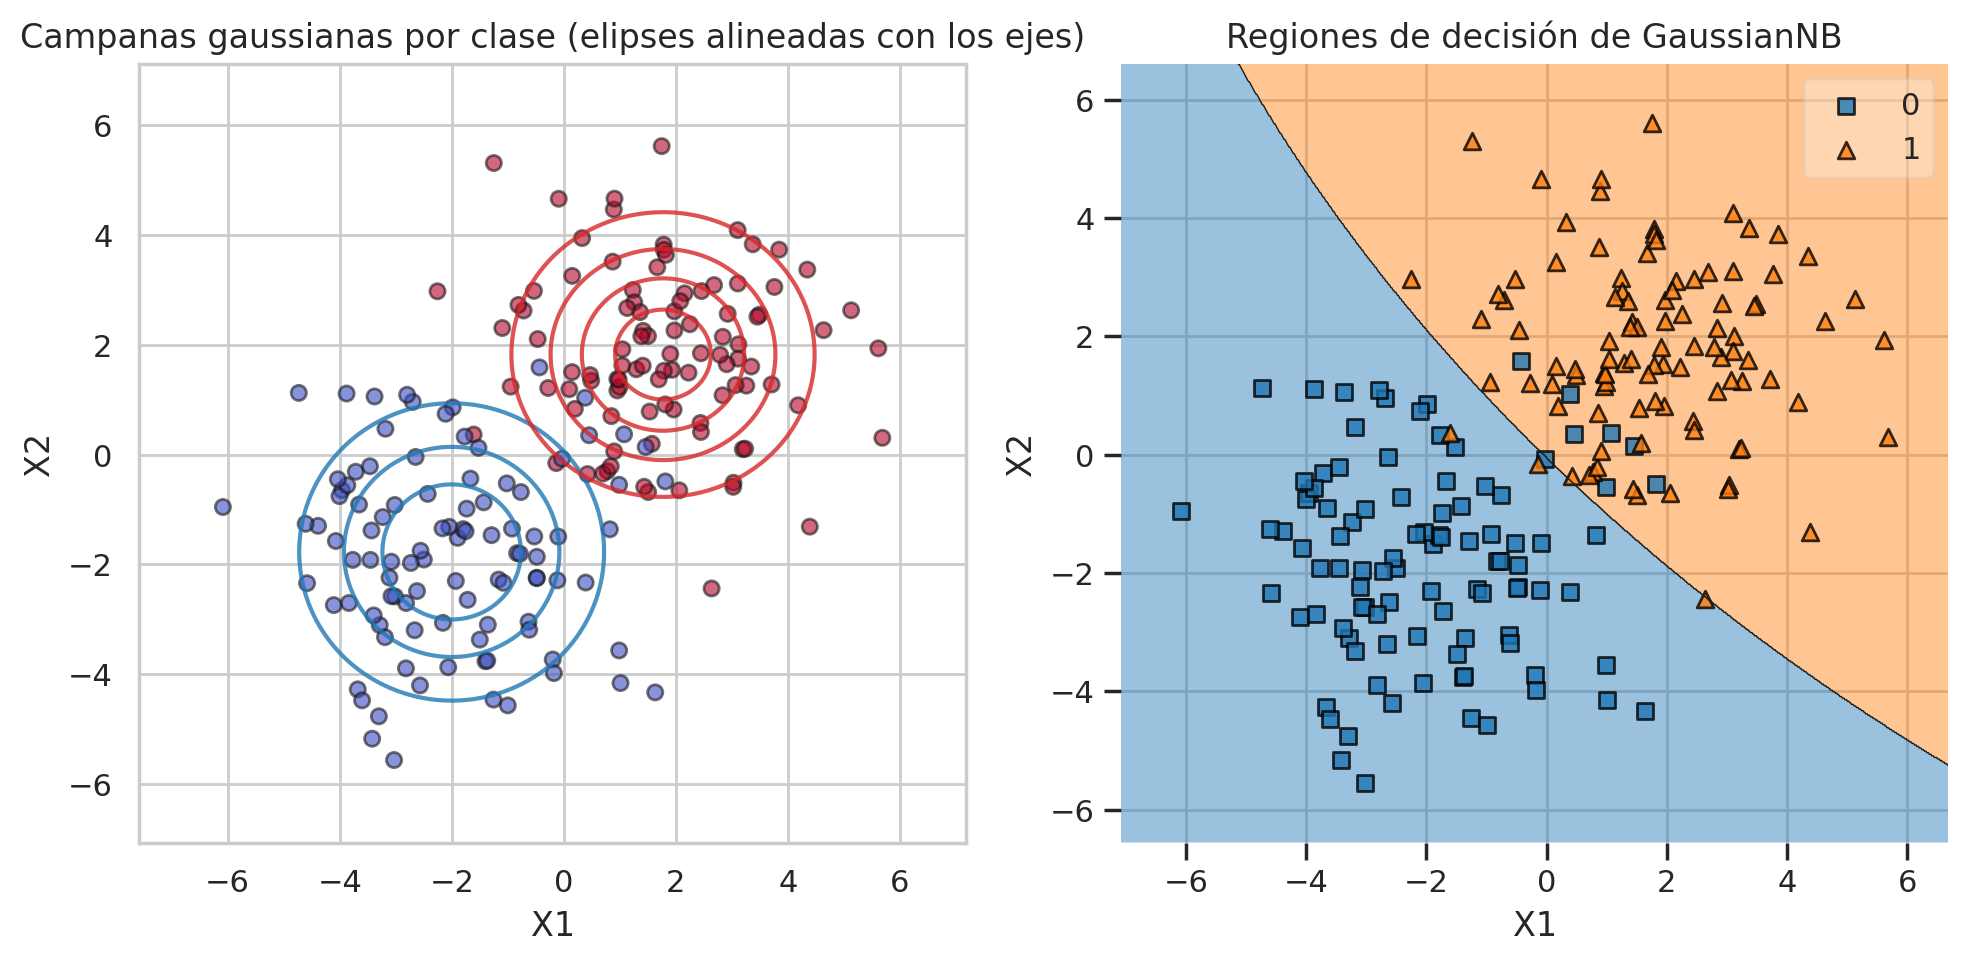

In [5]:
from sklearn.datasets import make_blobs
from scipy.stats import norm

# Generamos datos
X2, y2 = make_blobs(n_samples=200, centers=[[-2, -2], [2, 2]], cluster_std=1.6, random_state=0)
gnb = GaussianNB().fit(X2, y2)

# Función para generar elipses
def dibuja_gauss_nb(g, X, y, ax):
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='coolwarm', edgecolor='k', alpha=.6)
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1.5, X[:, 0].max()+1.5, 250),
                         np.linspace(X[:, 1].min()-1.5, X[:, 1].max()+1.5, 250))
    for k, col in zip(range(len(g.classes_)), ['#1f77b4', '#d62728']):
        Z = norm.pdf(xx, g.theta_[k, 0], np.sqrt(g.var_[k, 0])) * norm.pdf(yy, g.theta_[k, 1], np.sqrt(g.var_[k, 1]))
        ax.contour(xx, yy, Z, levels=4, colors=col, alpha=.8)

# Representación gráfica de la solución
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
dibuja_gauss_nb(gnb, X2, y2, ax[0]); ax[0].set_title('Campanas gaussianas por clase (elipses alineadas con los ejes)')
ax[0].set_xlabel('X1'); ax[0].set_ylabel('X2')
plot_decision_regions(X=X2, y=y2, clf=gnb, ax=ax[1]); ax[1].set_title('Regiones de decisión de GaussianNB')
ax[1].set_xlabel('X1'); ax[1].set_ylabel('X2'); plt.tight_layout(); plt.show()

Cada clase se resume en una **campana** (elipse) centrada en su media. Como NB supone independencia, las elipses **no se inclinan**: sus ejes son paralelos a $X_1$ y $X_2$. Para clasificar un punto, el modelo compara la **densidad ponderada por el prior** de cada campana en ese punto y elige la mayor; la frontera resultante es, en general, una **curva cuadrática**. *(De hecho, GaussianNB es equivalente a un **QDA** con la simplificación de covarianza **diagonal**: misma idea que el análisis discriminante, pero "olvidando" la correlación entre variables.)*

Comprobamos el cálculo **a mano** para un punto nuevo: sumamos el log-prior y los log de las densidades gaussianas de cada variable, y normalizamos.

In [6]:
x_nuevo = np.array([0.5, -0.5])
logpost = []
for k in range(len(gnb.classes_)):
    lp = np.log(gnb.class_prior_[k])
    for j in range(2):
        lp += norm.logpdf(x_nuevo[j], gnb.theta_[k, j], np.sqrt(gnb.var_[k, j]))
    logpost.append(lp)
logpost = np.array(logpost); post = np.exp(logpost - logpost.max()); post /= post.sum()
print('Posterior manual :', post.round(3))

Posterior manual : [0.486 0.514]


El punto queda casi en la frontera, por lo que su probabilidad está muy repartida.

## <font color="steelblue">2.2. El precio de ser "naïve": variables correlacionadas</font>

El adjetivo **«naïve»** (ingenuo) viene de una única suposición: que, **dentro de cada clase**, las variables son **independientes** entre sí. Gracias a ella la verosimilitud se factoriza como un simple producto, $P(x\mid y{=}k)=\prod_j P(x_j\mid y{=}k)$, lo que hace al modelo rapidísimo y estable incluso con muchas variables. El problema es que esa comodidad tiene un **precio** cuando la suposición no se cumple.

¿Cuándo falla el supuesto de independencia? Cuando las predictoras están **correlacionadas dentro de cada clase**. Geométricamente, la independencia obliga a que la nube de cada clase sea una **elipse con los ejes alineados** con los de coordenadas (covarianza **diagonal**). Si las variables están correlacionadas, la nube real es una **elipse inclinada**, y el Gaussian NB no puede representarla: la «endereza» a la fuerza, con dos consecuencias:

* **Sobra-confianza en las probabilidades.** Al tratar como independiente información que en realidad es **redundante**, el modelo «cuenta dos veces» la misma evidencia.
* **Frontera peor orientada.** Al no captar la inclinación de las nubes, la superficie de decisión queda **mal alineada** con la separación real entre clases, y aparecen errores justo en la zona donde las elipses inclinadas se solapan.

Lo ilustramos generando dos grupos con fuerte correlación (nube **inclinada**) y comparando `GaussianNB` (elipses alineadas con los ejes) con **QDA** (que sí estima la **covarianza completa**, con elipses inclinadas):

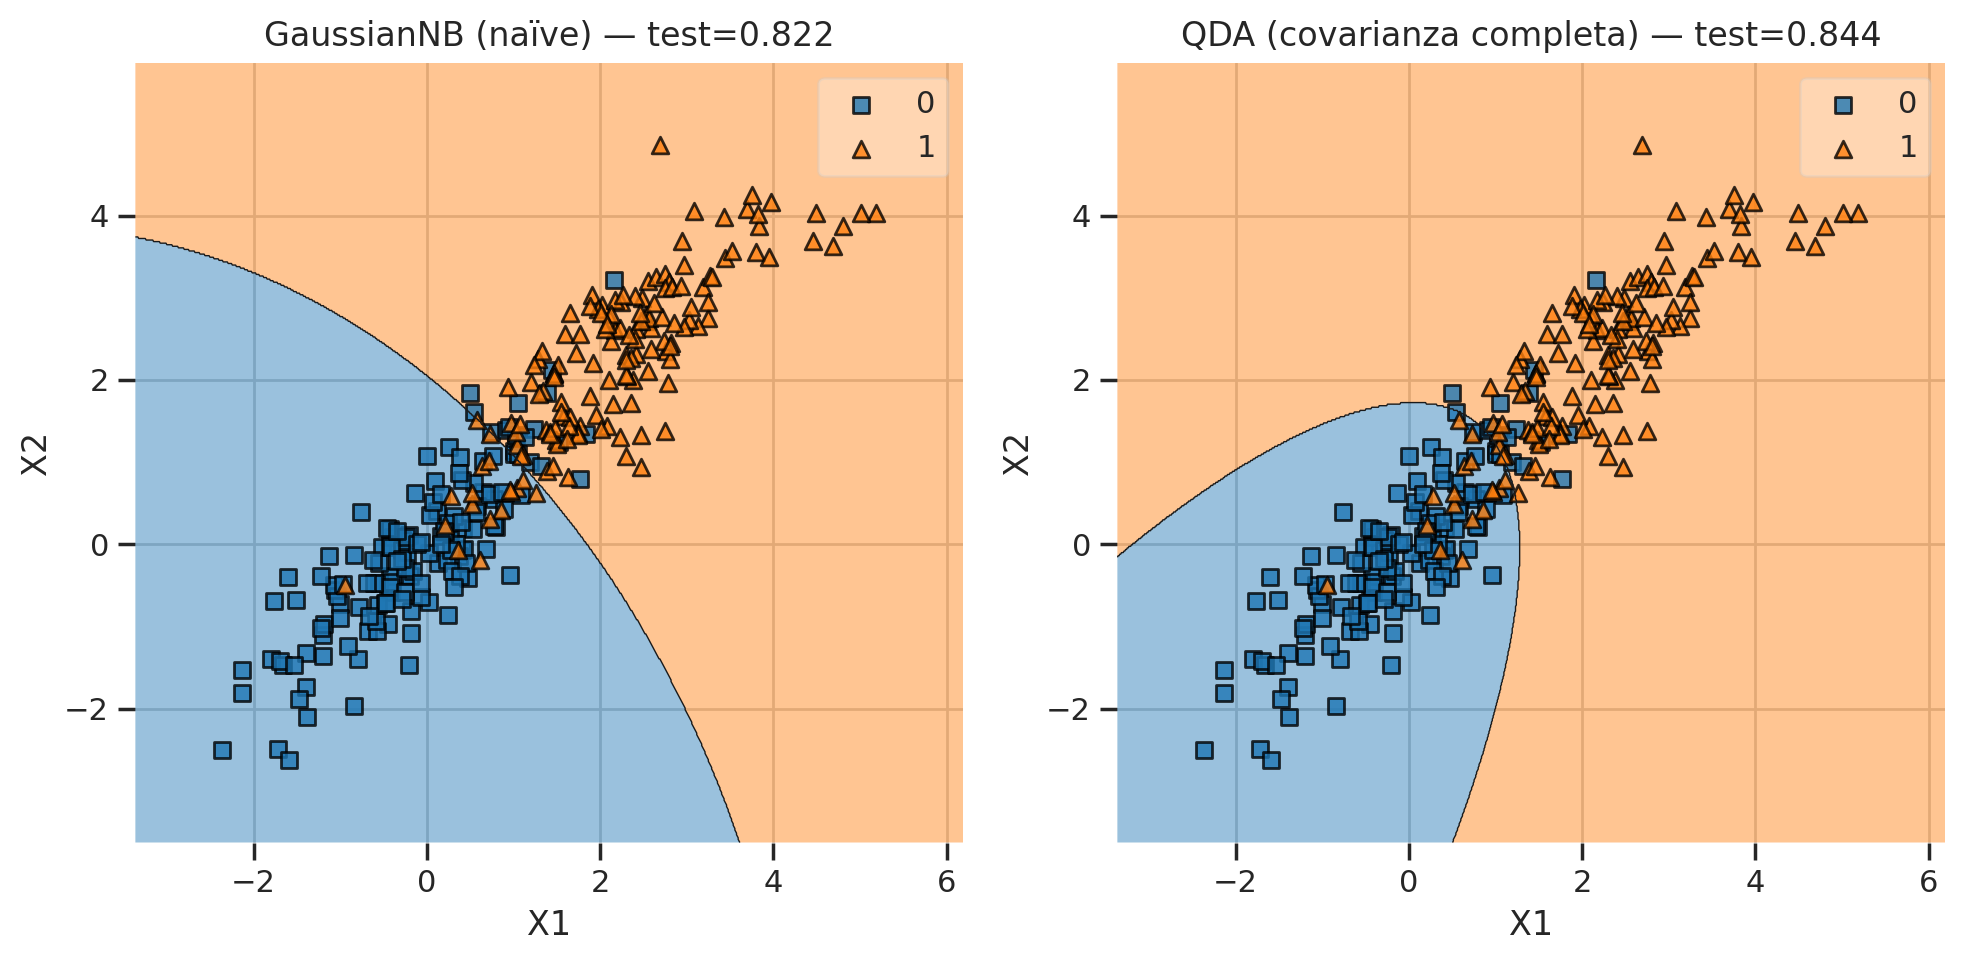

In [7]:
# Generamos datos correlacionados
rng = np.random.RandomState(1)
cov = np.array([[1, 0.85], [0.85, 1]])
A = rng.multivariate_normal([0, 0], cov, 150); B = rng.multivariate_normal([2.2, 2.2], cov, 150)
Xc = np.vstack([A, B]); yc = np.r_[np.zeros(150), np.ones(150)].astype(int)
xtr, xte, ytr, yte = train_test_split(Xc, yc, test_size=0.3, random_state=0)
# Entrenamos el modelo GaussinNB y los comparamos con el QDA
nb = GaussianNB().fit(xtr, ytr); qda = QuadraticDiscriminantAnalysis().fit(xtr, ytr)
# Representamos la solución
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plot_decision_regions(X=Xc, y=yc, clf=nb, ax=ax[0]); ax[0].set_title(f'GaussianNB (naïve) — test={nb.score(xte, yte):.3f}')
plot_decision_regions(X=Xc, y=yc, clf=qda, ax=ax[1]); ax[1].set_title(f'QDA (covarianza completa) — test={qda.score(xte, yte):.3f}')
for a in ax: a.set_xlabel('X1'); a.set_ylabel('X2')
plt.tight_layout(); plt.show()

Los datos forman nubes **inclinadas** (X1 y X2 correlacionan). GaussianNB, al imponer elipses **alineadas con los ejes**, no "ve" esa inclinación y traza una frontera algo peor; QDA, que estima la correlación, ajusta mejor y obtiene **algo más de exactitud**. Esta es la **pérdida** que paga el supuesto naïve. La buena noticia: aun siendo subóptimo, NB suele dar resultados **razonables y muy rápidos**, y en **alta dimensión** la diferencia tiende a diluirse.

# <font color="steelblue">3. Naïve Bayes en scikit-learn</font>

Todas las variantes viven en `sklearn.naive_bayes`, comparten la **misma interfaz** (`fit`/`predict`/`predict_proba`) y solo cambian en la distribución que asumen para $P(X_j\mid y)$. La tabla resume cuándo usar cada una y sus parámetros propios:

| Clase | Cuándo usarla | Parámetros clave |
|---|---|---|
| **`GaussianNB`** | Predictoras **numéricas** (normales) | `var_smoothing`, `priors` |
| **`MultinomialNB`** | **Recuentos** (texto: nº de palabras) | `alpha` (suavizado), `fit_prior` |
| **`BernoulliNB`** | Predictoras **binarias** (presencia/ausencia) | `alpha`, `binarize` |
| **`ComplementNB`** | Recuentos con **clases desbalanceadas** | `alpha`, `norm` |
| **`CategoricalNB`** | Categóricas con varias categorías | `alpha`, `min_categories` |

**Parámetros de los constructores:**

**Comunes a las variantes de recuento/categóricas** (`Multinomial`, `Bernoulli`, `Complement`, `Categorical`):
* **`alpha`** `float`, def. `1.0` — constante de **suavizado** (sección 1.4): `1.0` = Laplace, `0<α<1` = Lidstone. Es el hiperparámetro que se ajusta por validación cruzada.
* **`force_alpha`** `bool`, def. `True` — si `True`, respeta valores de `alpha` muy pequeños; si `False`, los eleva a un mínimo (`1e-10`) por estabilidad numérica.
* **`fit_prior`** `bool`, def. `True` — si `True`, aprende las probabilidades a priori $\pi_k$ de las **frecuencias** de clase; si `False`, usa un **prior uniforme** (todas las clases igual de probables *a priori*).
* **`class_prior`** `array (n_classes,)`, def. `None` — fija las probabilidades a priori a mano (tiene prioridad sobre `fit_prior`). Es la palanca para **compensar el desbalanceo** en estas variantes (no hay `class_weight`).

**Propios de cada clase:**
* `GaussianNB` → **`priors`** (a priori a mano) y **`var_smoothing`** `float`, def. `1e-9`: fracción de la mayor varianza que se **suma a todas las varianzas** para estabilizar el cálculo (evita dividir por ~0 en variables casi constantes). Es su análogo de `alpha`.
* `BernoulliNB` → **`binarize`** `float`, def. `0.0`: umbral para convertir las entradas a `0/1`. Si le pasas recuentos, los **binariza** a presencia/ausencia; con `binarize=None` asume que ya son binarias.
* `ComplementNB` → **`norm`** `bool`, def. `False`: si `True`, normaliza los pesos internos (segunda corrección del método, útil a veces en texto).
* `CategoricalNB` → **`min_categories`** `int` o `array`, def. `None`: número mínimo de categorías por variable (para reservar sitio a categorías que podrían aparecer en test pero no salieron en train).

**Métodos comunes**

* **`fit(X, y[, sample_weight])`** — estima los parámetros de cada distribución por clase.
* **`partial_fit(X, y, classes=…)`** — entrenamiento **incremental** por lotes (para datos que no caben en memoria o llegan en *streaming*).
* **`predict(X)`** — **clase** predicha.
* **`predict_proba(X)`** / **`predict_log_proba(X)`** — **probabilidades** posteriores por clase (y su log). Recuerda: en Naive Bayes suelen estar **mal calibradas** (muy cerca de 0/1), útiles para **ordenar** pero no como probabilidad literal.
* **`predict_joint_log_proba(X)`** — el log de la probabilidad **conjunta** $\log P(x, y{=}k)$ antes de normalizar (diagnóstico).
* **`score(X, y)`** — **exactitud** media.
* **`get_params()` / `set_params(**kwargs)`** — para `Pipeline` y `GridSearchCV`.

**Atributos tras ajustar**

* **`classes_`** — etiquetas de clase ordenadas.
* **`class_count_`** — nº de muestras por clase; **`class_log_prior_`** (o **`class_prior_`** en Gaussian) — las $\pi_k$ (en log) usadas.
* En **`GaussianNB`**: **`theta_`** `(n_clases, n_features)` (**medias** $\mu_{jk}$), **`var_`** `(n_clases, n_features)` (**varianzas** $\sigma_{jk}^2$) y **`epsilon_`** (el suavizado absoluto añadido). Con esto quedan definidas las «campanas» de cada variable en cada clase.
* En **`Multinomial`/`Complement`/`Bernoulli`**: **`feature_count_`** (recuentos por clase y variable) y **`feature_log_prob_`** `(n_clases, n_features)` (log de las probabilidades $\theta_{kj}$ **ya suavizadas**). En `CategoricalNB`, el análogo es **`feature_log_prob_`** como **lista** (una tabla por variable).
* **`n_features_in_`** / **`feature_names_in_`** — nº y nombres de las variables vistas en `fit`.

**Uso común:** `modelo = GaussianNB().fit(X_train, y_train)`; `modelo.predict(X_test)`; `modelo.predict_proba(X_test)`. La **evaluación y validación** las haremos con las funciones habituales del curso.

# <font color="steelblue">4. Estudios de caso</font>

## <font color="steelblue">4.1. Cáncer de mama (GaussianNB)</font>

Clasificamos tumores como **benignos (B)** o **malignos (M)** a partir de 30 predictoras numéricas. El clasificador natural es el **gaussiano**. Las clases están **desbalanceadas** (más benignos), así que validaremos con **Recall** o **F1 ponderada**. Preparamos los datos con y dado el desbalanceo introducimos el parámetro `class_prior` con los porcentajes registrados.

In [10]:
# Cargar datos
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/cancer_clean.csv'
cancer = pd.read_csv(url, index_col=0)
cancer['diagnosis'] = cancer['diagnosis'].astype('category')
# Preparación de datos
strain_raw, stest_raw = split_sample(cancer, 'diagnosis', 0.3, 0, True)
strain, prep = preprocesar_datos(strain_raw, 'diagnosis')
stest,  _    = preprocesar_datos(stest_raw,  'diagnosis', prep)
xtrain, ytrain = strain.drop('diagnosis', axis=1), strain['diagnosis']
xtest,  ytest  = stest.drop('diagnosis', axis=1),  stest['diagnosis']
# Frecuencias iniciales en la muestra de entrenamiento
prop_ini = list(ytrain.value_counts()/len(ytrain))
# Entrenamiento del modelo con desbalanceo
modelo = GaussianNB(priors=prop_ini).fit(xtrain, ytrain)
print('Entrenamiento:', xtrain.shape, '| Test:', xtest.shape)

# Definimos la métrica recall sobre tumores malignos
from sklearn.metrics import make_scorer
recall_m_scorer = make_scorer(recall_score, pos_label='M')

Estratificando por 'diagnosis'.
  Entrenamiento: 398 muestras | Test: 171 muestras
Entrenamiento: (398, 30) | Test: (171, 30)


### Evaluación del modelo

Comenzamos obteniendo el informe de clasificación tanto de entrenamiento como de test.

In [11]:
reports_clas(modelo, xtrain, ytrain, xtest, ytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           B       0.94      0.96      0.95       250
           M       0.93      0.90      0.91       148

    accuracy                           0.94       398
   macro avg       0.94      0.93      0.93       398
weighted avg       0.94      0.94      0.94       398


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           B       0.93      0.90      0.91       107
           M       0.84      0.89      0.86        64

    accuracy                           0.89       171
   macro avg       0.89      0.89      0.89       171
weighted avg       0.90      0.89      0.90       171



Las métricas asociadas tanto en entrenamiento como en validación son bastante altas indicando la buena clasificación del modelo.

Veamos con detalle la matriz de confusión:

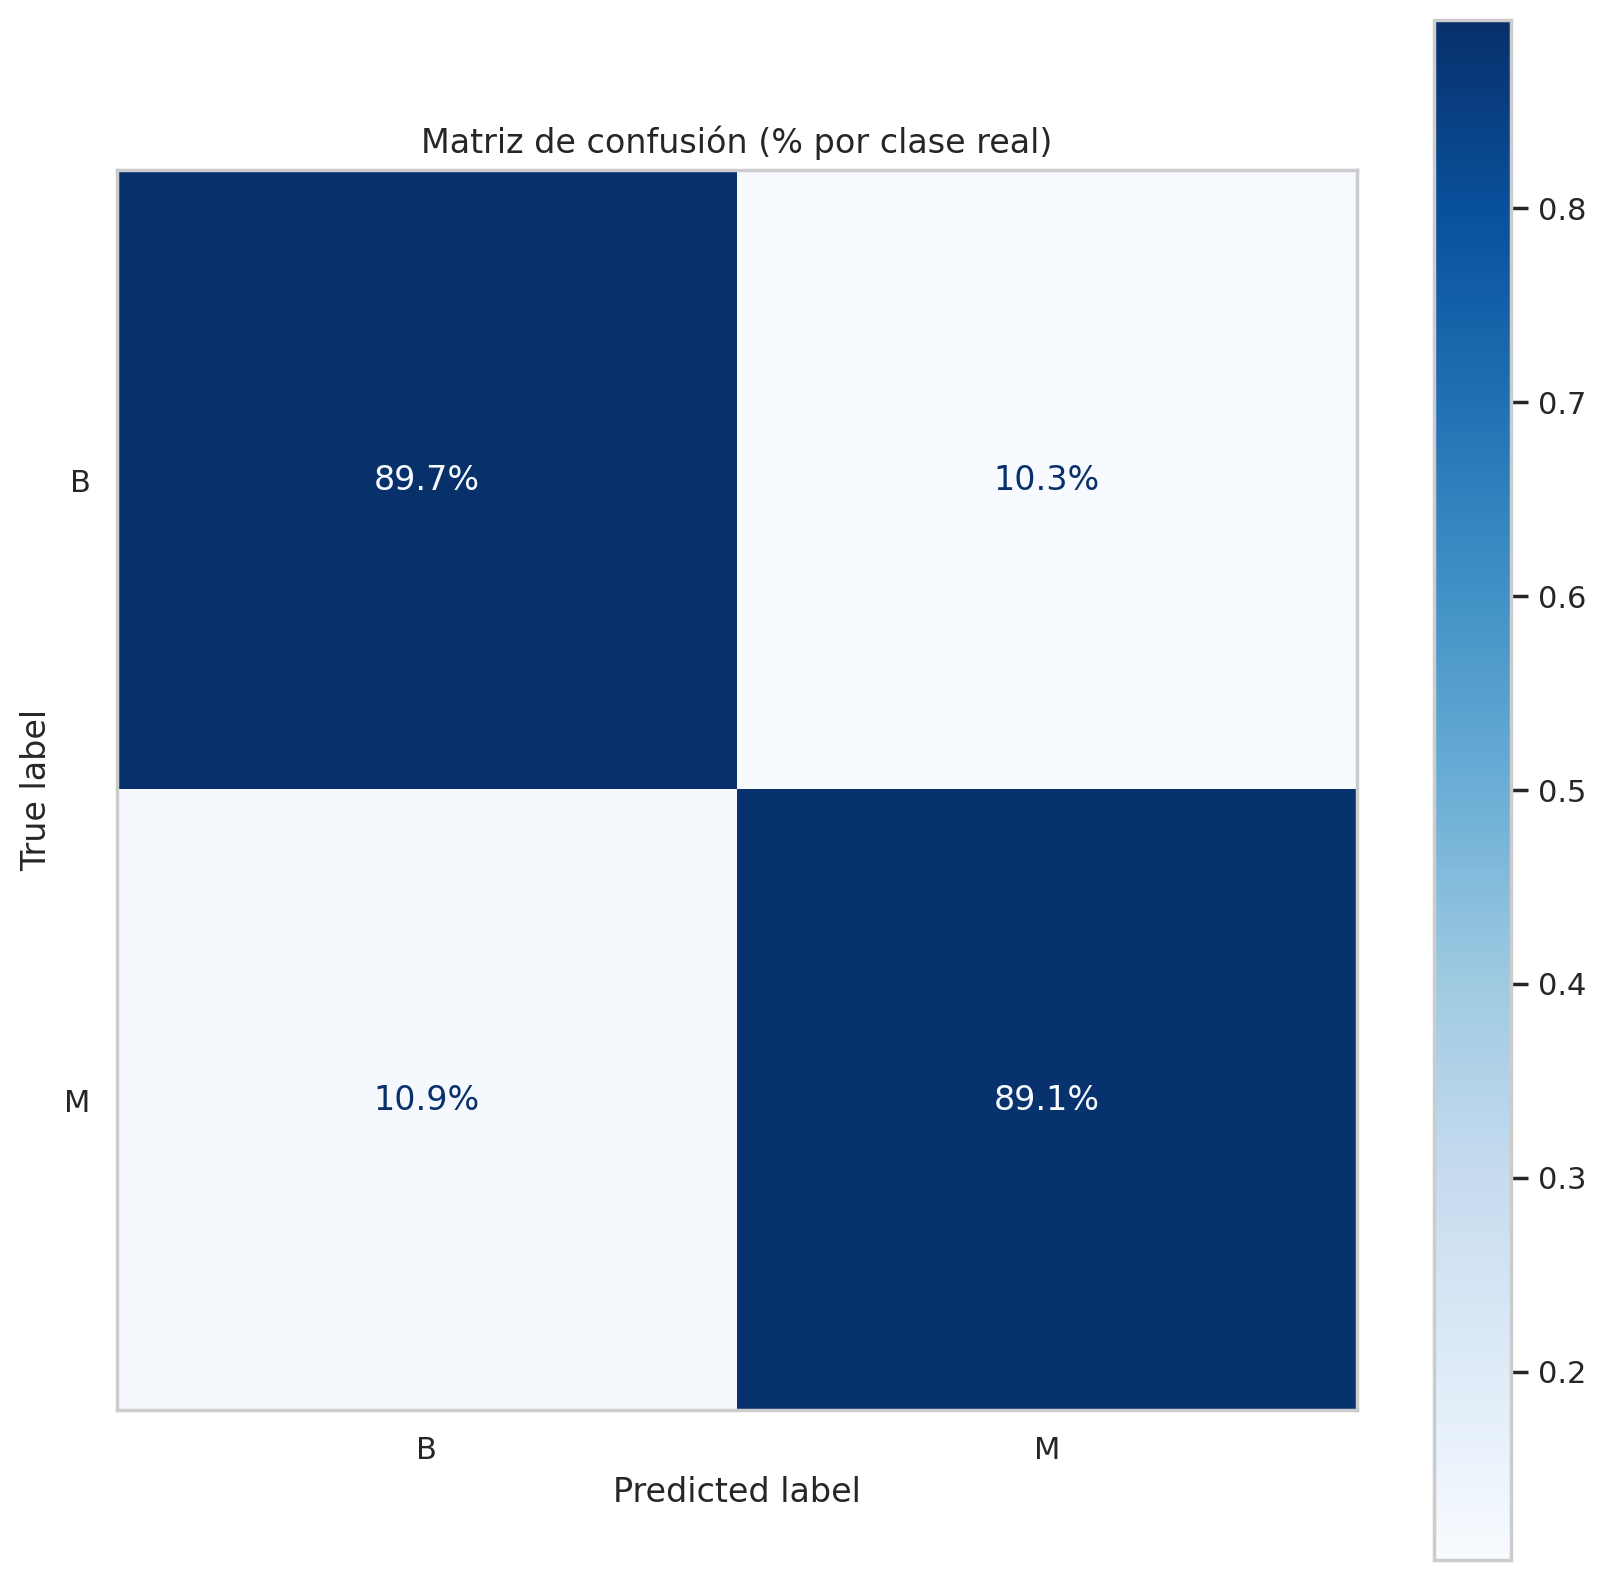

In [12]:
matriz_confusion(modelo, xtest, ytest);

El aspecto más relevante es que el 10.9% de los pacientes con tumor maligno son clasificados como benignos (falsos negativos).

Obtenemos ahora la curva ROC y el AUC aociado:

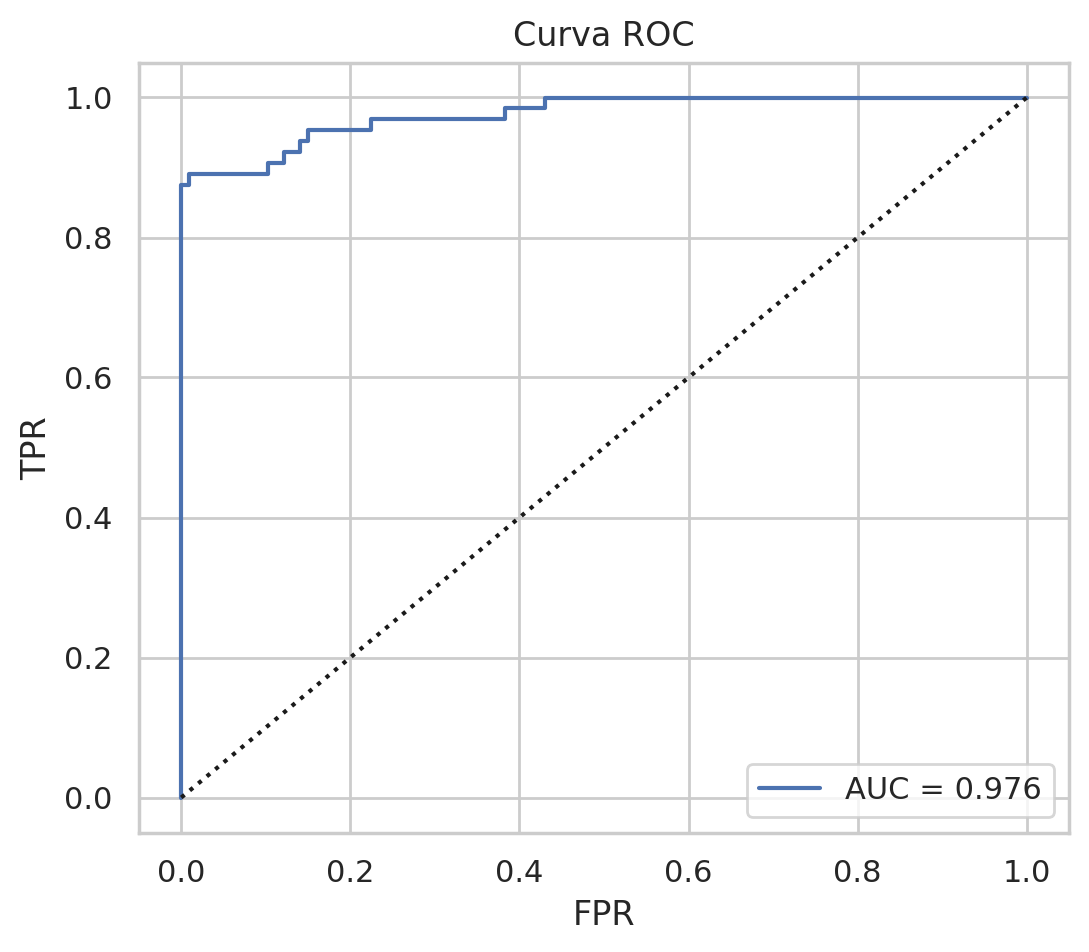

In [13]:
y_prob = modelo.predict_proba(xtest)[:, 1]
fpr, tpr, _ = roc_curve(ytest, y_prob, pos_label='M')
plt.figure(figsize=(6, 5)); plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score((ytest=="M").astype(int), y_prob):.3f}')
plt.plot([0, 1], [0, 1], 'k:'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Curva ROC'); plt.legend(); plt.show()

El área bajo la curva es de 0.976 indicando que el modelo tiene un porcentaje muy alto de clasificar correctamente a los pacientes.

Procedemos ahora con el estudio de validación.

In [14]:
val = validar_modelo(modelo, xtrain, ytrain, 'recall', 10)

Validacion cruzada (10 folds, score=recall): media = 0.899 +/- 0.075


La validación cruzada muestra una métrica recall alta y **estable** (poca dispersión) en torno al 90% indicando un buen comportamiento del modelo.



## <font color="steelblue">4.2. Detección de spam (MultinomialNB)</font>

Ahora la predictora es **texto**: el cuerpo de cada correo. Antes de clasificar hay que convertir el texto en números.

### ¿Cómo se vectoriza un texto? (bolsa de palabras)

La idea del modelo **bolsa de palabras** (*bag of words*) es simple: se construye un **vocabulario** con todas las palabras que aparecen, y cada documento se representa por un vector que **cuenta cuántas veces** aparece cada palabra. Lo vemos con tres mensajes de juguete usando `CountVectorizer`:

In [20]:
from sklearn.feature_extraction.text import CountVectorizer

demo = ['oferta gratis gratis ya', 'reunion proyecto manana', 'gratis premio oferta gratis']
v_demo = CountVectorizer()
M = v_demo.fit_transform(demo)
pd.DataFrame(M.toarray(), columns=v_demo.get_feature_names_out(), index=['mensaje 1', 'mensaje 2', 'mensaje 3'])

,gratis,manana,oferta,premio,proyecto,reunion,ya
mensaje 1,2,0,1,0,0,0,1
mensaje 2,0,1,0,0,1,1,0
mensaje 3,2,0,1,1,0,0,0


Cada **fila** es un mensaje, cada **columna** una palabra del vocabulario y cada celda el **número de apariciones** (la matriz se llama *documento-término*). Así, "gratis" aparece 2 veces en el mensaje 1 y 2 en el 3, pero 0 en el 2. Esta matriz de **recuentos** es justo lo que necesita el clasificador **Multinomial**.

Podemos enriquecer la representación contando también **pares de palabras consecutivas** (*bigramas*) con `ngram_range=(1,2)`, lo que ayuda a captar expresiones como "click aquí". Esto aumenta el vocabulario:

In [21]:
for ng in [(1, 1), (1, 2)]:
    print(f'ngram_range={ng}: vocabulario de {len(CountVectorizer(ngram_range=ng).fit(demo).get_feature_names_out())} términos')

ngram_range=(1, 1): vocabulario de 7 términos
ngram_range=(1, 2): vocabulario de 14 términos


### Datos reales de spam

Analizamos un banco de datos real que contiene un conjunto de mensaje de email caraterizados como spam y no spam. En primer lugar cargamos los datos (mensaje de correo) y su etiquetado.

In [22]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/spam_or_not_spam.csv'
spam = pd.read_csv(url).dropna()
print('Mensajes:', len(spam), '| balance (0=no spam, 1=spam):', spam.label.value_counts(normalize=True).round(3).to_dict())
spam.head(3)

Mensajes: 2999 | balance (0=no spam, 1=spam): {0: 0.834, 1: 0.166}


,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0


Vectorizamos todos los correos (palabras y bigramas) y dividimos en entrenamiento/test estratificando por la respuesta.

In [25]:
# Vectorizamos y preparamos los datos
vectorizer = CountVectorizer(ngram_range=(1, 2))
X_vec = vectorizer.fit_transform(spam['email'])
y_spam = spam['label']
print('Matriz documento-término:', X_vec.shape, '(documentos × términos)')
xtr_s, xte_s, ytr_s, yte_s = train_test_split(X_vec, y_spam, test_size=0.30, random_state=42, stratify=y_spam)
# Frecuencias iniciales en la muestra de entrenamiento
prop_ini = list(ytrain.value_counts()/len(ytrain))
# Entrenamiento del modelo con desbalanceo
modelo_spam = MultinomialNB(class_prior=prop_ini).fit(xtr_s, ytr_s)

Matriz documento-término: (2999, 264869) (documentos × términos)


Una vez entrenado el modelo pasamos a describir su comportamiento. Comenzamos con los informes de clasificación:

In [26]:
reports_clas(modelo_spam, xtr_s, ytr_s, xte_s, yte_s)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1750
           1       1.00      0.99      1.00       349

    accuracy                           1.00      2099
   macro avg       1.00      1.00      1.00      2099
weighted avg       1.00      1.00      1.00      2099


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       750
           1       0.97      0.96      0.97       150

    accuracy                           0.99       900
   macro avg       0.98      0.98      0.98       900
weighted avg       0.99      0.99      0.99       900



El modelo se comporta de forma muy precisa (métricas por encima del 98%), lo que muestra una grana capacidad de discriminación entre correos spam y no spam. Verificamos los resulatdos con la matriz de confusión:

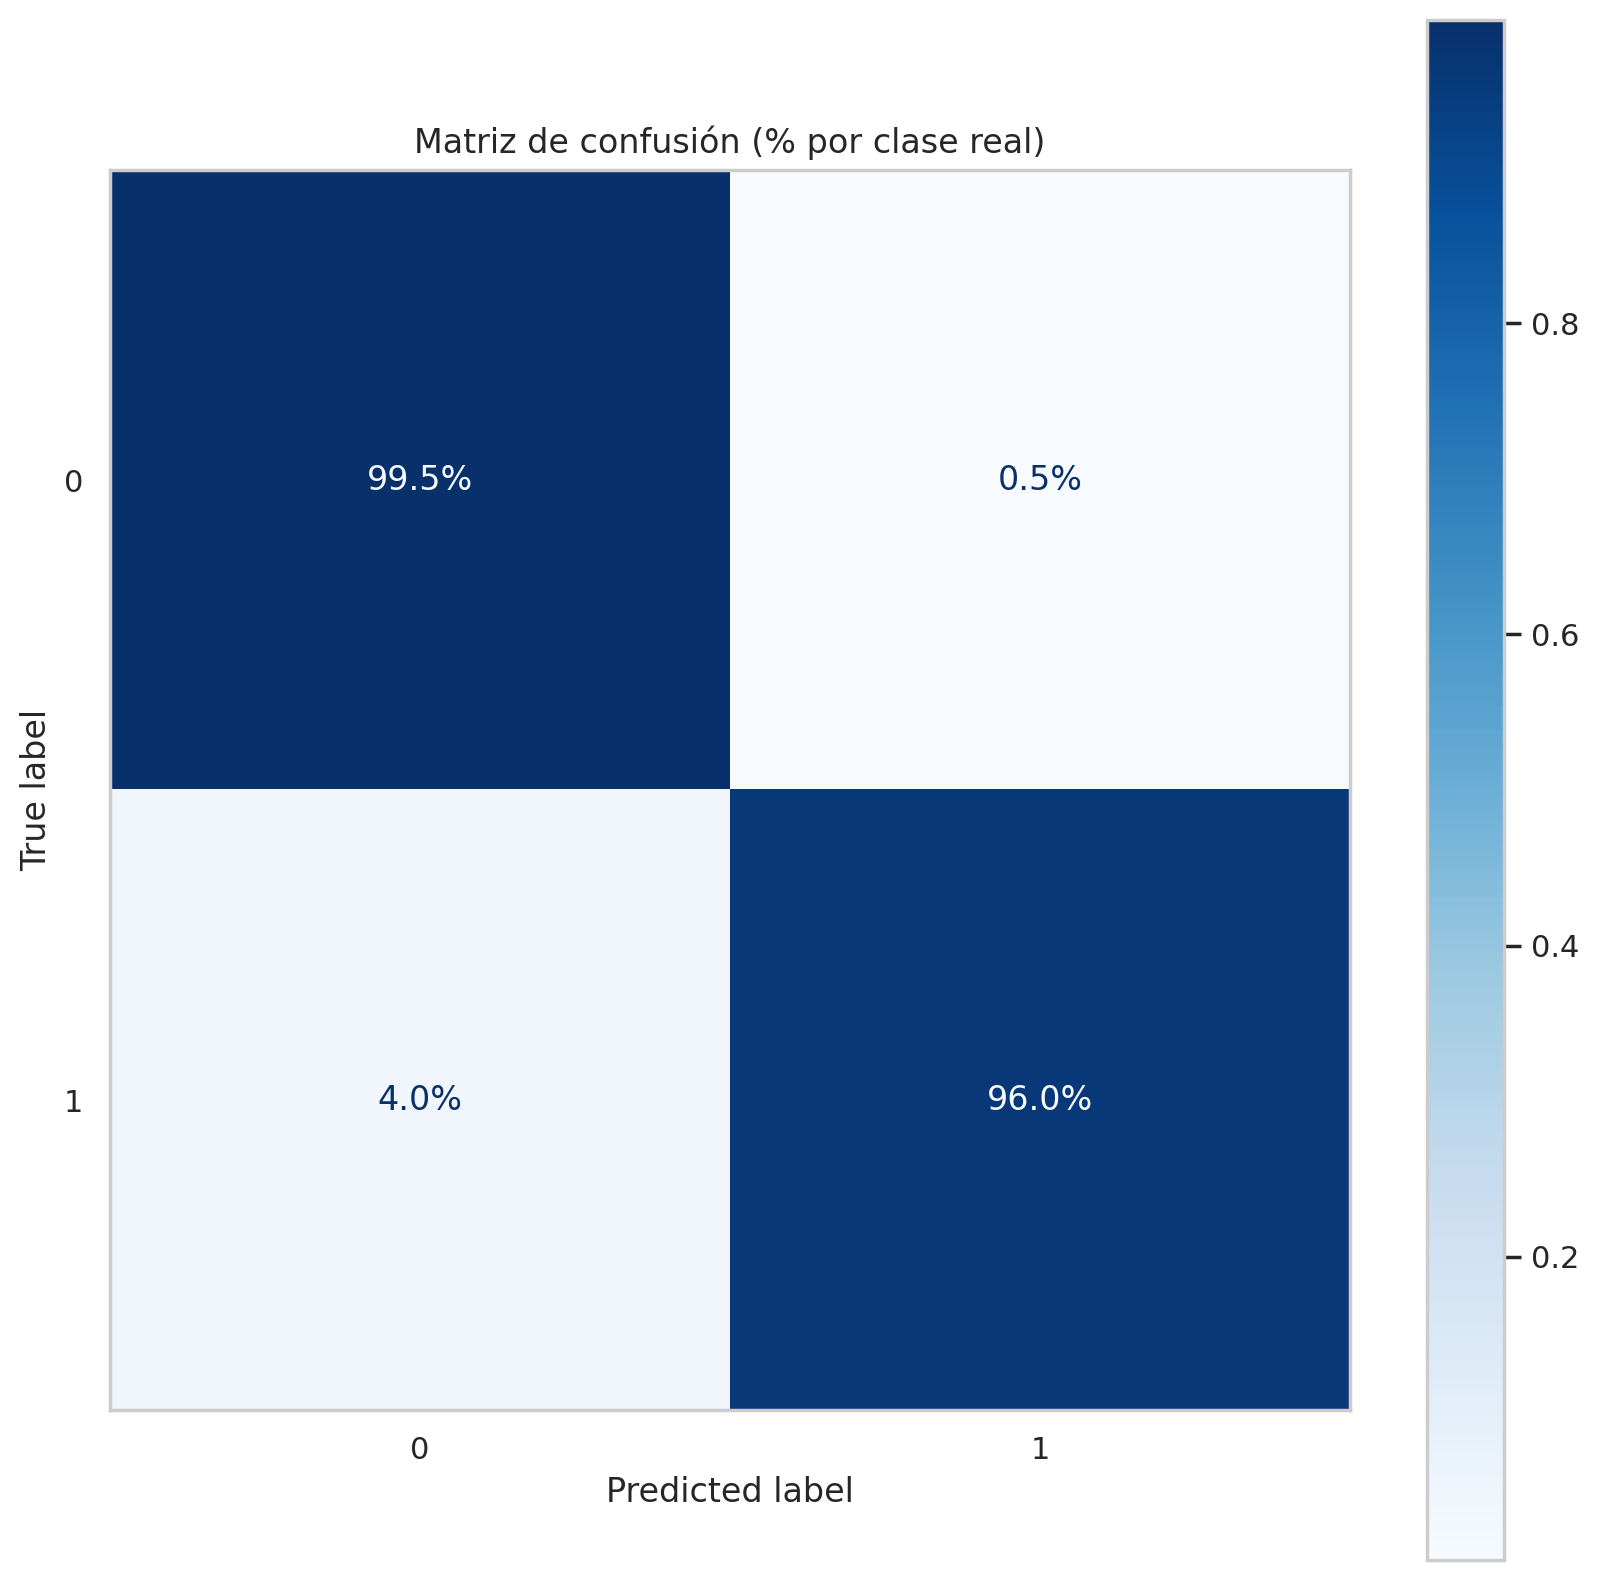

In [27]:
matriz_confusion(modelo_spam, xte_s, yte_s);

El modelo entrenado tiene un 4% de errores de clasificar como no spam correos que han sido etiquetados como spam. Veamos el análisis de validación cruzada:

In [29]:
val_spam = validar_modelo(modelo_spam, xtr_s, ytr_s, 'recall', 10)

Validacion cruzada (10 folds, score=recall): media = 0.971 +/- 0.029


Con un clasificador tan simple obtenemos una clasificación **casi perfecta**, **estable** en validación cruzada



### Ajuste del suavizado `alpha`

El suavizado de Laplace/Lidstone es el hiperparámetro `alpha`. Lo ajustamos por validación cruzada:

In [34]:
recall_spam_scorer = make_scorer(recall_score, pos_label=1)
pgrid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
gs = GridSearchCV(MultinomialNB(), pgrid, scoring=recall_spam_scorer, cv=10)
gs.fit(xtr_s, ytr_s)
print('Mejores hiperparámetros:', gs.best_params_, '| recall CV (M):', round(gs.best_score_, 3))

Mejores hiperparámetros: {'alpha': 0.1} | recall CV (M): 0.989


El çoptimo se alcanza con un valor de $\alpha$ de 0.1, con un recall de validación cruzada de 0.989, lo que indica la validez del modleo de detección de spam.

### Comparación de variantes Naïve Bayes

Como las clases están **desbalanceadas**, comparamos el Multinomial con el **Bernoulli** (que solo mira presencia/ausencia de cada palabra, ignorando cuántas veces aparece) y el **Complement** (variante pensada para datos desbalanceados):

In [35]:
comp = []
for nombre, clf in [('MultinomialNB', MultinomialNB()), ('BernoulliNB', BernoulliNB()), ('ComplementNB', ComplementNB())]:
    clf.fit(xtr_s, ytr_s); pred = clf.predict(xte_s)
    comp.append({'modelo': nombre, 'exactitud': round(accuracy_score(yte_s, pred), 4),
                 'f1_ponderada': round(f1_score(yte_s, pred, average='weighted'), 4),
                 'recall_spam': round(recall_score(yte_s, pred), 4)})
pd.DataFrame(comp)

,modelo,exactitud,f1_ponderada,recall_spam
0,MultinomialNB,0.9900,0.9900,0.9600
1,BernoulliNB,0.8489,0.8179,0.2267
2,ComplementNB,0.9900,0.9900,0.9667


El **Multinomial** y el **Complement** rinden de forma excelente, mientras que el **Bernoulli** queda claramente por detrás: al quedarse solo con *si una palabra aparece o no* (y no *cuántas veces*), pierde información valiosa para este problema, donde la **frecuencia** de ciertas palabras es muy indicativa. Es un buen recordatorio de que conviene elegir la **variante acorde al tipo de predictora**.

### ¿Qué palabras delatan el spam?

Naïve Bayes es **interpretable**: comparando, para cada término, su log-probabilidad en la clase spam frente a la clase no-spam (`feature_log_prob_`), obtenemos los tokens más **indicativos de spam**.

In [36]:
terminos = np.array(vectorizer.get_feature_names_out())
informativos = modelo_spam.feature_log_prob_[1] - modelo_spam.feature_log_prob_[0]
top = terminos[np.argsort(informativos)[-15:]][::-1]
print('Términos más indicativos de SPAM:')
print(list(top))

Términos más indicativos de SPAM:
['hyperlink hyperlink', 'hyperlink', 'hyperlink click', 'enenkio', 'click here', 'of enenkio', 'the kingdom', 'kingdom of', 'atoll', 'marshall islands', 'number orders', 'hermios', 'the marshall', 'kingdom', 'not wish']


Los términos más asociados al spam (enlaces, llamadas a la acción como "click here", etc.) coinciden con la intuición. Esta transparencia es otra ventaja de Naïve Bayes frente a modelos de "caja negra".



### Nubes de términos

Visualizamos las dos caras del problema con sendas **nubes de palabras**: a la izquierda, el **vocabulario por frecuencia** (cuanto mayor el término, más veces aparece en el corpus); a la derecha, los **términos que más determinan el spam** (tamaño proporcional a su poder discriminante hacia esa clase, según `feature_log_prob_`).

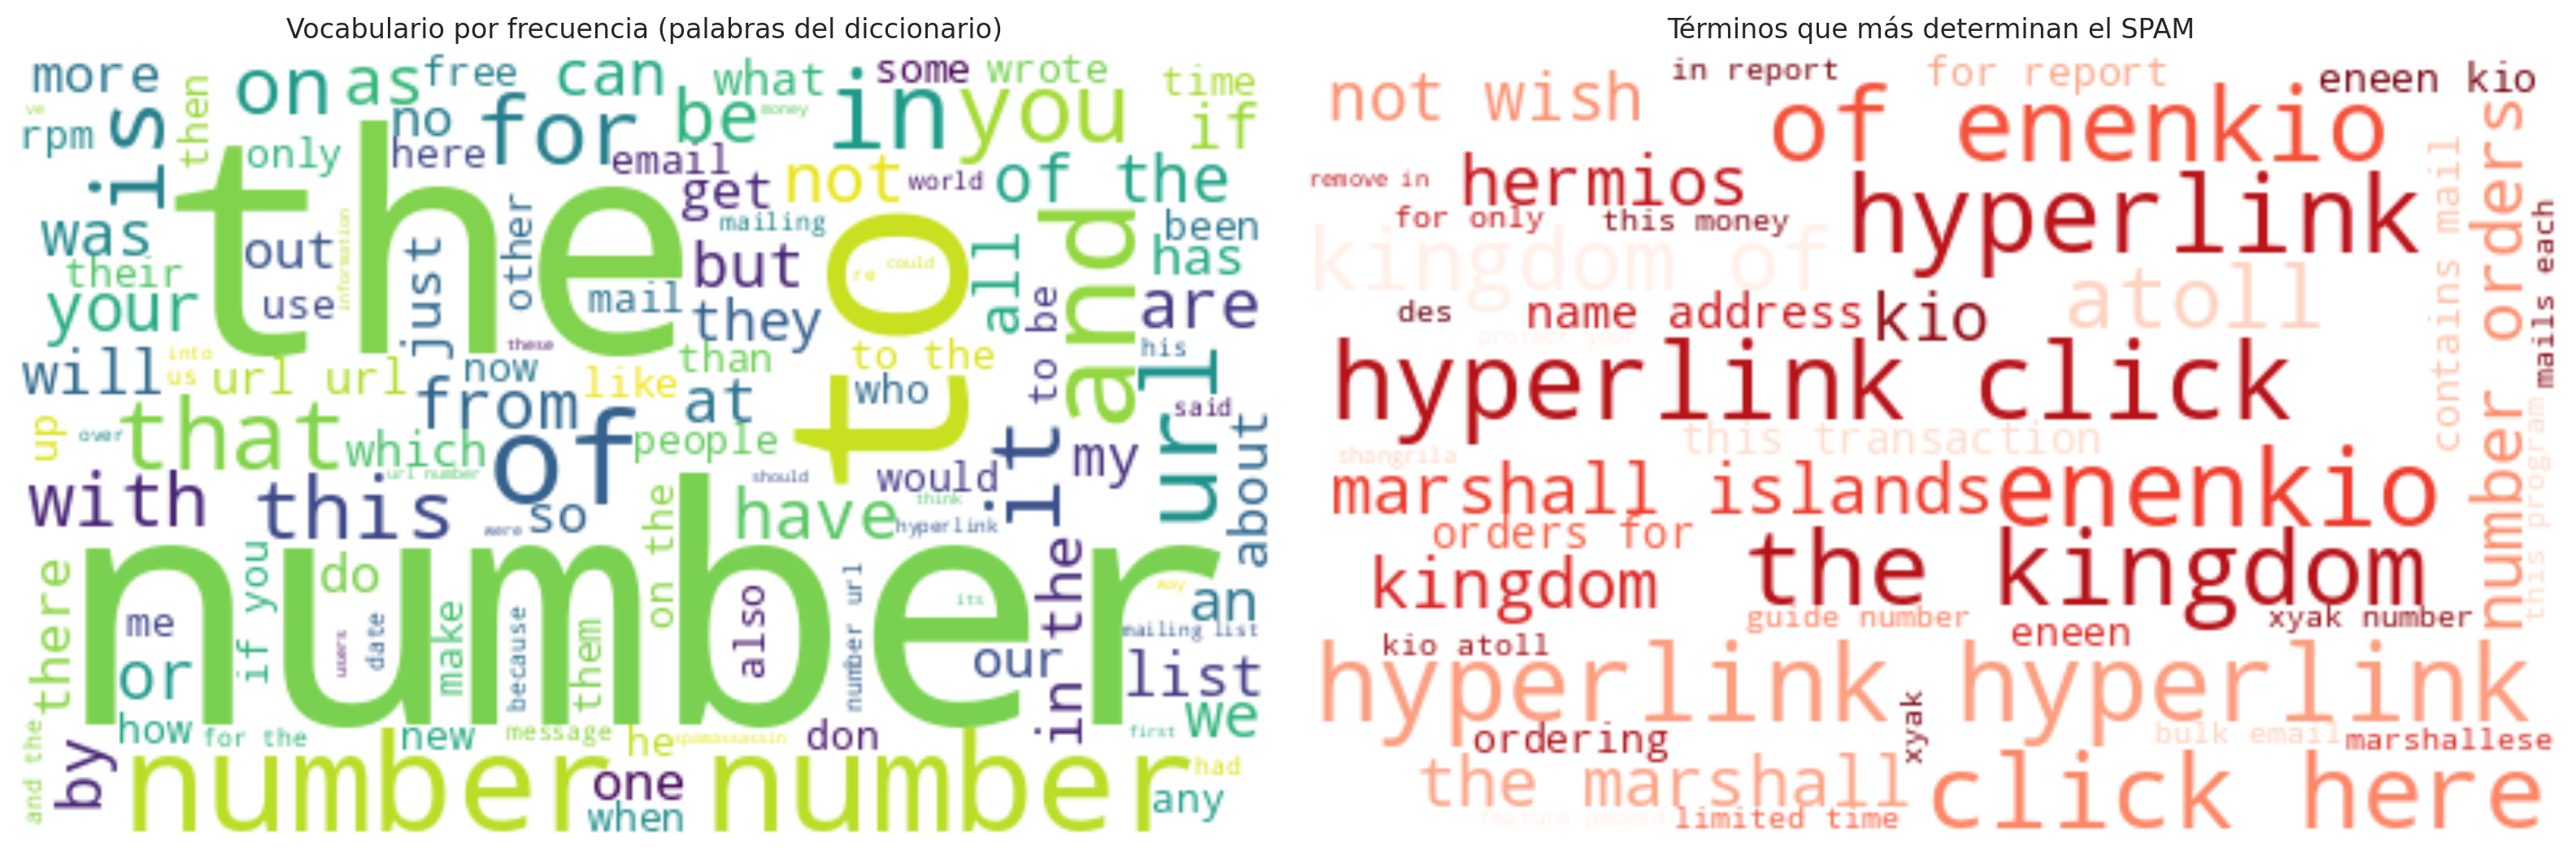

In [38]:
from wordcloud import WordCloud

terminos = np.array(vectorizer.get_feature_names_out())

# (1) vocabulario por frecuencia total en el corpus
total = np.asarray(X_vec.sum(axis=0)).ravel()
freq_voc = dict(zip(terminos, total))

# (2) términos que más determinan el spam (diferencia de log-probabilidad, solo positivos)
infor = modelo_spam.feature_log_prob_[1] - modelo_spam.feature_log_prob_[0]
idx = np.argsort(infor)[-200:]
freq_spam = {terminos[i]: float(infor[i]) for i in idx if infor[i] > 0}

fig, ax = plt.subplots(1, 2, figsize=(16, 7))
nube_voc = WordCloud(width=400, height=250, background_color='white', max_words=120,
                     colormap='viridis').generate_from_frequencies(freq_voc)
ax[0].imshow(nube_voc, interpolation='bilinear'); ax[0].axis('off')
ax[0].set_title('Vocabulario por frecuencia (palabras del diccionario)')
nube_spam = WordCloud(width=400, height=250, background_color='white', max_words=100,
                      colormap='Reds').generate_from_frequencies(freq_spam)
ax[1].imshow(nube_spam, interpolation='bilinear'); ax[1].axis('off')
ax[1].set_title('Términos que más determinan el SPAM')
plt.tight_layout(); plt.show()

La nube del **vocabulario** (izquierda) está dominada por **palabras muy comunes** —artículos, preposiciones y marcadores como `number` o `url`—: aparecen muchísimo pero **no discriminan** entre spam y no-spam. La nube de la **derecha**, en cambio, resalta los términos realmente **indicativos de spam** (enlaces, llamadas a la acción…), que son los que el clasificador usa de verdad para decidir. El contraste entre ambas ilustra la diferencia entre **frecuencia** y **capacidad discriminante**.

## <font color="steelblue">4.3. Abulones (GaussianNB, tres clases)</font>

Clasificamos el **sexo** de abulones (M/F/I) a partir de medidas físicas numéricas. Usamos de nuevo el clasificador **gaussiano**.

In [39]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/abalone_clean.csv'
abalone = pd.read_csv(url, index_col=0); abalone['Sex'] = abalone['Sex'].astype('category')
astrain_raw, astest_raw = split_sample(abalone, 'Sex', 0.3, 0, True)
astrain, aprep = preprocesar_datos(astrain_raw, 'Sex')
astest,  _     = preprocesar_datos(astest_raw,  'Sex', aprep)
axtrain, aytrain = astrain.drop('Sex', axis=1), astrain['Sex']
axtest,  aytest  = astest.drop('Sex', axis=1),  astest['Sex']
amodelo = GaussianNB().fit(axtrain, aytrain)

Estratificando por 'Sex'.
  Entrenamiento: 2923 muestras | Test: 1254 muestras


In [40]:
reports_clas(amodelo, axtrain, aytrain, axtest, aytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           F       0.46      0.67      0.55       915
           I       0.63      0.81      0.71       939
           M       0.41      0.14      0.21      1069

    accuracy                           0.52      2923
   macro avg       0.50      0.54      0.49      2923
weighted avg       0.50      0.52      0.48      2923


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           F       0.43      0.61      0.50       392
           I       0.62      0.81      0.71       403
           M       0.43      0.15      0.22       459

    accuracy                           0.51      1254
   macro avg       0.49      0.53      0.48      1254
weighted avg       0.49      0.51      0.47      1254



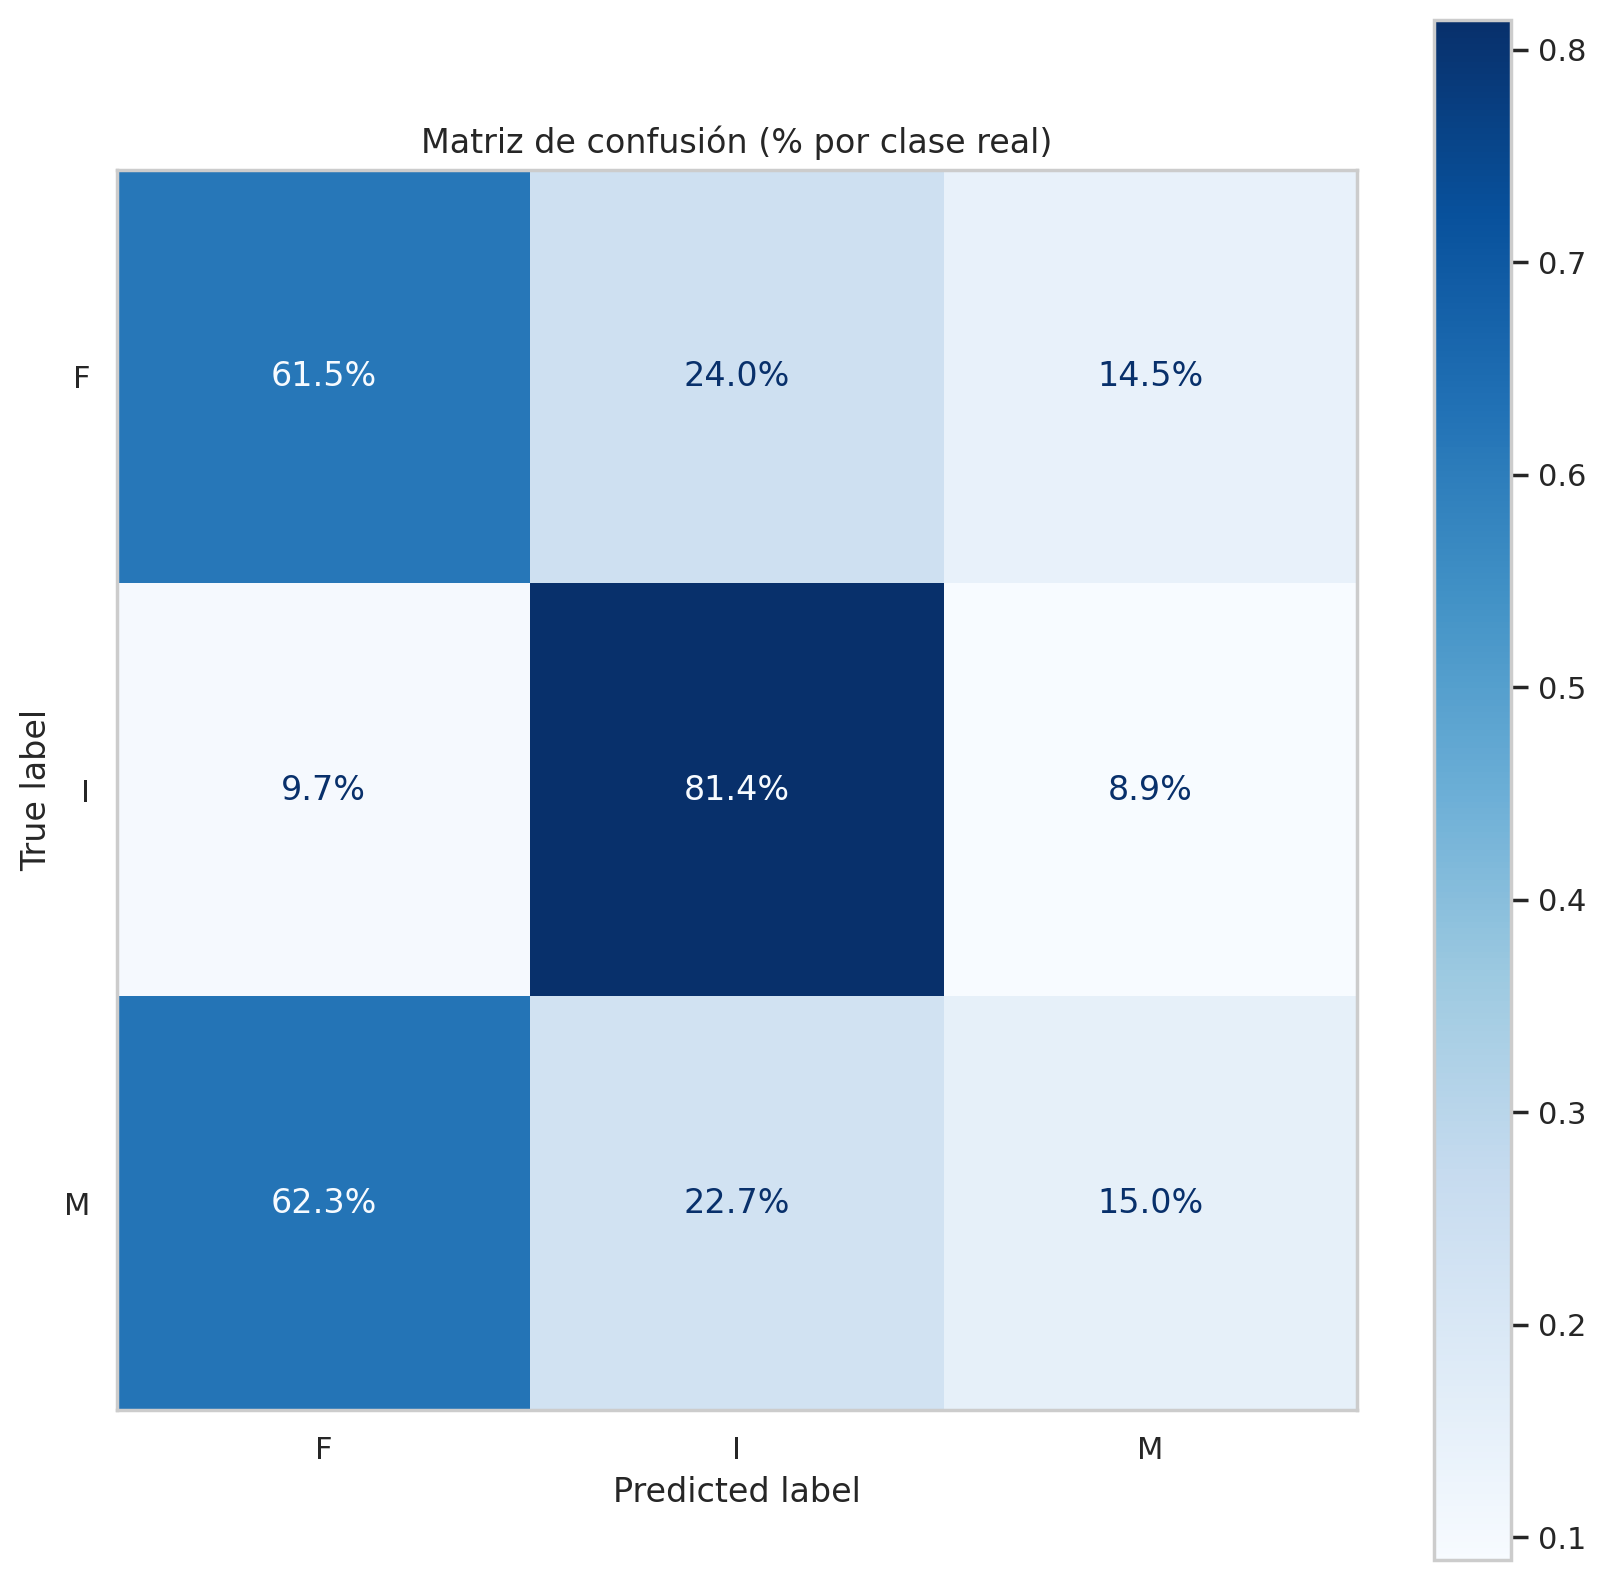

In [41]:
matriz_confusion(amodelo, axtest, aytest);

In [42]:
aval = validar_modelo(amodelo, axtrain, aytrain, 'f1_weighted', 10)

Validacion cruzada (10 folds, score=f1_weighted): media = 0.520 +/- 0.018


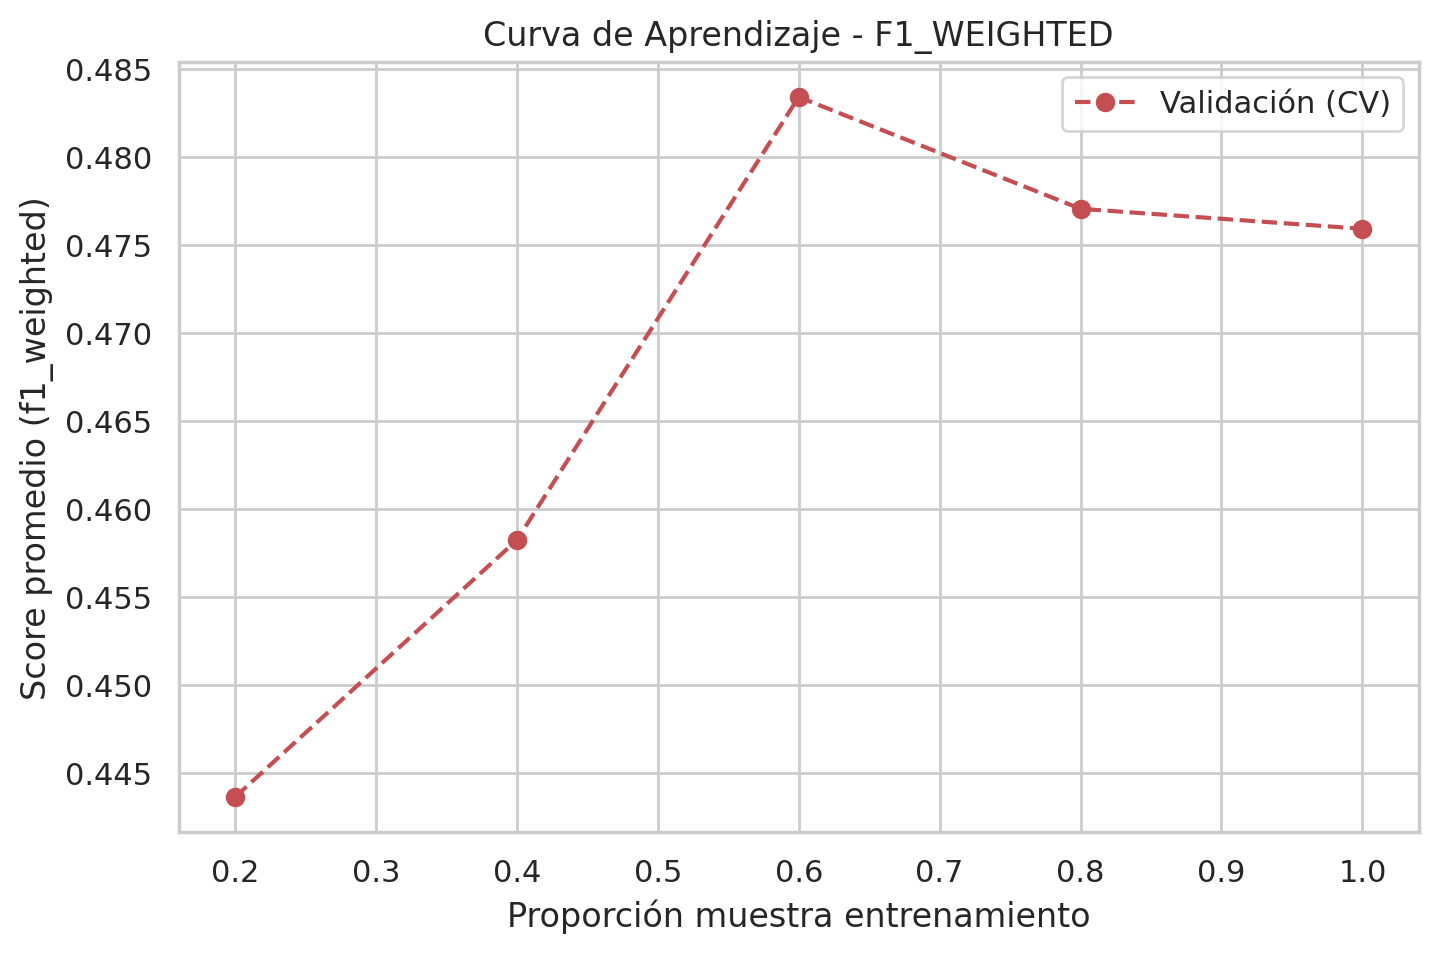

In [43]:
adatos_pp, _ = preprocesar_datos(abalone, 'Sex'); aX = adatos_pp.drop('Sex', axis=1); aY = adatos_pp['Sex']
curva_aprendizaje(amodelo, aX, aY, 'f1_weighted', 10);

Aquí la clasificación es **pobre** (en torno al 50 %): la matriz de confusión muestra que **M y F se confunden** mucho (son físicamente muy parecidos) y solo los **infantiles (I)** se distinguen algo mejor. La curva de aprendizaje queda **plana y baja**: ni el clasificador gaussiano arreglaría un problema en el que **las predictoras no separan bien las clases**. Es un recordatorio honesto de la primera condición para que Naïve Bayes funcione —que las variables estén realmente relacionadas con la respuesta—.



# <font color="steelblue">5. Referencias</font>

* Barber, D. (2012). *Bayesian Reasoning and Machine Learning*. Cambridge University Press.
* James, Witten, Hastie & Tibshirani (2021). *An Introduction to Statistical Learning*. Springer.
* Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. O'Reilly.
* scikit-learn — *Naïve Bayes*: https://scikit-learn.org/stable/modules/naive_bayes.html